In [31]:
from importlib.metadata import version
import torch
import torch.nn as nn



context_vecs = torch.load('../../datasets/context_vecs.pt')

print(context_vecs[:50])


tensor([[[-7.6414e-01,  2.9154e-01, -1.9037e-01,  3.1077e-01,  3.5080e-01,
           9.9317e-02,  5.0221e-02,  3.0308e-01,  1.9244e-01,  4.7636e-02,
          -7.1880e-02, -2.9143e-01,  5.2602e-01,  7.5202e-02,  2.2773e-01,
          -2.0110e-01, -6.3697e-02, -2.8900e-01, -3.3126e-01, -4.2194e-01,
          -2.3386e-01,  4.5508e-02,  5.2981e-01,  4.4535e-01,  4.4046e-01,
           4.3316e-01, -5.2813e-01, -4.7818e-01, -1.5627e-01,  6.0605e-01,
          -8.3516e-02,  2.9352e-01,  7.0454e-01,  6.9913e-02, -3.4901e-01,
          -2.1434e-01, -6.7013e-01,  3.9920e-01, -7.8823e-01,  6.7225e-02,
           3.5327e-01, -2.5369e-01,  3.9062e-01,  3.3338e-01,  2.6941e-01,
          -1.4387e-01,  8.0987e-01,  9.1302e-02, -2.2594e-01, -3.0039e-01,
           6.6410e-01, -1.1495e-01,  1.0442e-01,  5.6625e-01, -4.3983e-01,
          -5.6057e-01,  8.9655e-01,  8.2673e-04, -5.6083e-02, -3.8740e-01,
           5.6725e-01, -4.5790e-01, -5.8352e-01, -4.8122e-01, -4.1335e-01,
           1.3154e-01,  5

konfigurationsdatei

In [32]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

Zahlen können während des Trainings sehr groß oder sehr klein werden → das Modell wird instabil.LayerNorm rechnet die Werte immer auf einen Mittelwert von 0 und eine Varianz von 1 um

In [33]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

GELU, sie entscheidet welche Informationen weitergegeben werden und welche nicht.
negative Zahlen → fast 0 (blockiert)
positive Zahlen → durchgelassen

In [34]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

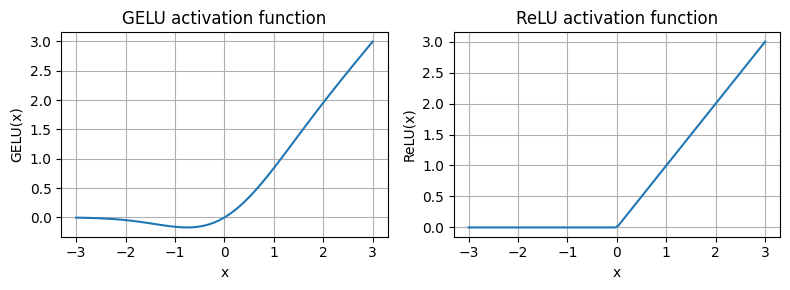

In [35]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

FeedForward ist ein kleines neuronales Netz das nach der Attention kommt.Dimension wieder verkleinern (3072 → 768)

In [36]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)



In [37]:
import sys
sys.path.append('../../ch04/01_main-chapter-code/')
from previous_chapters import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

self.tok_emb   → Token Embedding (Wort → Vektor)
self.pos_emb   → Position Embedding (wo steht das Wort?)
self.drop_emb  → Dropout (gegen Overfitting)
self.trf_blocks → 12x TransformerBlock hintereinander
self.final_norm → LayerNorm am Ende
self.out_head   → gibt für jedes Token Wahrscheinlichkeiten aus (768 → 50257)

Text rein → Embeddings → 12x Transformer → Normalisierung → Wahrscheinlichkeiten raus

In [38]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

generate_text_simple generiert neuen Text Wort für Wort.

Input:  "Hello, I am"
Schritt 1: Modell sagt → "a" ist am wahrscheinlichsten
Output: "Hello, I am a"

Schritt 2: Modell sagt → "good" ist am wahrscheinlichsten  
Output: "Hello, I am a good"

usw...

In [39]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [41]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

torch.save(model.state_dict(), '../../datasets/model.pt')